In [1]:
import itertools

import pandas as pd
import numpy as np
import seaborn as sns
import h5py
from scipy.stats import ttest_ind
from pathlib import Path
import mne
import torch
from tqdm.auto import tqdm
import re

from src.data import add_metadata_features
from src.stimuli import POD_dict

In [2]:
eois_path = "outputs/trf_eois/eois.csv"
phoneme_epoch_path = "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5"
pval_threshold = 1e-2

# If True, use Barakeet EOI data to pre-filter the channels we look at in epoched form
# to find significant barakeet responses. Otherwise, start from scratch and run hella
# t-tests on all the barakeet epochs just as we do with TIMIT here.
filter_barakeet_by_eoi = True

In [3]:
all_epoch_paths = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))

In [4]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))

    try:
        epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)
    except:
        print(f"Could not add metadata features for {subject_name}")
        del epochs[subject_name]

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC279_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
864 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 83 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC243_epo.fif ...
    Reading extended channel information
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 71 columns
864 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 82 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC260_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     990.

In [5]:
all_md = pd.concat([epochs[subject_name].metadata for subject_name in epochs])

In [6]:
eoi_df = pd.read_csv(eois_path, index_col=["subject", "electrode", "feature_block"])
# only retain feature blocks showing positive UV
eoi_df = eoi_df[eoi_df.unique_variance > 1e-3].sort_index()
eoi_df

unique_variance
subject electrode feature_block                    
EC243   87        acoustic                 0.002908
        90        behavior                 0.001488
        102       acoustic                 0.003536
                  mismatch                 0.011920
        103       mismatch                 0.003927
...                                             ...
EC282   119       lexical_evidence         0.002894
        145       mismatch                 0.002271
EC287   25        lexical_evidence         0.001189
        56        behavior                 0.001718
        121       lexical_evidence         0.001638

[125 rows x 1 columns]

## Discover TIMIT tuning

Discover tuning preferences in TIMIT epochs for all phoneme pair contrasts.

In [8]:
contrast_windows = [(0.1, 0.2), (0.2, 0.3), (0.3, 0.4)]
contrast_results = []

for subject in tqdm(epochs.keys()):
    if subject not in eoi_df.index.get_level_values("subject"):
        print("DEV: missing ", subject)
        continue

    try:
        ph_epoch_df = pd.read_hdf(phoneme_epoch_path, key=f"{subject}/epoch_df")
    except KeyError:
        print(f"Could not find epoch_df for {subject}")
        continue

    for phoneme_pair in tqdm(all_md.phoneme_pair.unique(), leave=False):
        phoneme1, phoneme2 = list(phoneme_pair.upper())

        ph1_epoch_idxs = ph_epoch_df[ph_epoch_df.epoch_label == phoneme1].index
        ph2_epoch_idxs = ph_epoch_df[ph_epoch_df.epoch_label == phoneme2].index

        with h5py.File(phoneme_epoch_path, "r") as f:
            epoch_tmin = f[subject].attrs["epoch_tmin"]
            sfreq = f[subject].attrs["sfreq"]
            ph1_epochs = f[f"{subject}/epochs"][ph1_epoch_idxs, :, :]
            ph2_epochs = f[f"{subject}/epochs"][ph2_epoch_idxs, :, :]

        for contrast_start, contrast_end in contrast_windows:
            start_sample = int((contrast_start - epoch_tmin) * sfreq)
            end_sample = int((contrast_end - epoch_tmin) * sfreq)

            ph1_contrast = ph1_epochs[:, :, start_sample:end_sample].mean(axis=2).T
            ph2_contrast = ph2_epochs[:, :, start_sample:end_sample].mean(axis=2).T

            for channel in range(ph1_contrast.shape[0]):
                t, p = ttest_ind(ph1_contrast[channel, :], ph2_contrast[channel, :])

                contrast_results.append({
                    "subject": subject,
                    "phoneme_pair": phoneme_pair,
                    "contrast_start": contrast_start,
                    "contrast_end": contrast_end,
                    "channel": channel,
                    "t": t,
                    "p": p,
                })

contrast_results_df = pd.DataFrame(contrast_results)

  0%|          | 0/10 [00:00<?, ?it/s]

Could not find epoch_df for EC279


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
contrast_results_df["sign"] = np.sign(contrast_results_df.t)
contrast_results_df["preference"] = np.where(contrast_results_df.sign == 1, contrast_results_df.phoneme_pair.str[0], contrast_results_df.phoneme_pair.str[1])

In [10]:
sig_timit_contrasts = contrast_results_df.dropna().query("p < @pval_threshold").sort_values("p")
sig_timit_contrasts = sig_timit_contrasts.drop(columns="sign")
sig_timit_contrasts["site"] = sig_timit_contrasts.subject.str.cat(sig_timit_contrasts.channel.astype(str), sep="_")
sig_timit_contrasts

,subject,phoneme_pair,contrast_start,contrast_end,channel,t,p,preference,site
11397,EC248,bm,0.1,0.2,381,9.231869,9.633152e-19,b,EC248_381
10061,EC278,dn,0.1,0.2,53,8.727167,1.036865e-17,d,EC278_53
11781,EC248,bm,0.2,0.3,381,8.204404,2.321820e-15,b,EC248_381
9557,EC278,bm,0.1,0.2,53,7.525959,2.366736e-13,b,EC278_53
13701,EC248,pb,0.1,0.2,381,-7.288954,1.977309e-12,b,EC248_381
...,...,...,...,...,...,...,...,...,...
3455,EC260,bm,0.3,0.4,277,2.594589,9.741327e-03,b,EC260_277
465,EC243,bm,0.2,0.3,183,2.597176,9.755904e-03,b,EC243_183
12638,EC248,dn,0.2,0.3,86,-2.589010,9.759111e-03,n,EC248_86
16089,EC282,pb,0.1,0.2,81,-2.590479,9.934446e-03,b,EC282_81


In [11]:
sig_timit_contrasts.groupby("site").apply(lambda xs: xs.preference.value_counts().idxmax()) \
    .value_counts()

/tmp/ipykernel_2237973/1678974591.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sig_timit_contrasts.groupby("site").apply(lambda xs: xs.preference.value_counts().idxmax()) \


b    71
n    55
p    36
m    19
d    16
Name: count, dtype: int64

/tmp/ipykernel_2237973/446750892.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sns.barplot(data=sig_timit_contrasts.groupby("site").apply(lambda xs: xs.preference.value_counts().idxmax()) \


<Axes: xlabel='index', ylabel='count'>

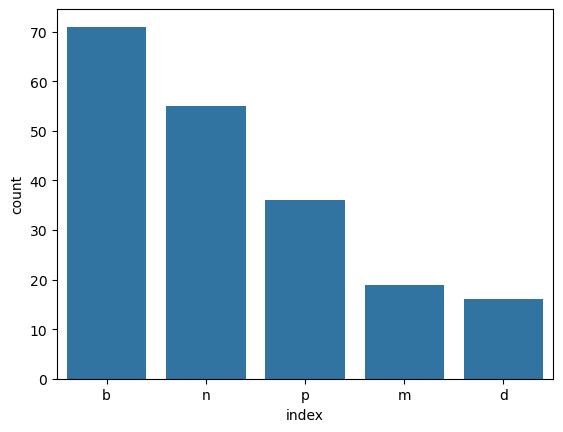

In [12]:
sns.barplot(data=sig_timit_contrasts.groupby("site").apply(lambda xs: xs.preference.value_counts().idxmax()) \
    .value_counts().reset_index(),
            x="index", y="count")

## Load pre-computed TIMIT tuning

In [13]:
big_trf_model = "vanilla"
## HACK
feature_names = ['onset',
 'phnfeatConsOnset',
 'phnfeatConsOnset_1',
 'phnfeatConsOnset_2',
 'phnfeatConsOnset_3',
 'phnfeatConsOnset_4',
 'phnfeatConsOnset_5',
 'maxDtL',
 'formantMedOnset',
 'formantMedOnset_1',
 'formantMedOnset_2',
 'formantMedOnset_3',
 'F0',
 'word_surprisal',
 'word_log_frequency',
 'word_entropy']

# extract relevant phonetic features
ph_features = {
    "labial": "phnfeatConsOnset_2",
    "coronal": "phnfeatConsOnset_1",
    "nasal": "phnfeatConsOnset_5",
    "plosive": "phnfeatConsOnset_3",
    "F0": "F0",
}

In [15]:
timit_coef_results = []
for subject in tqdm(epochs.keys()):
    try:
        with open(f"/userdata/jgauthier/projects/big-trf/outputs/encoders/timit-no_repeats/word/{subject}/coefs.pkl", "rb") as f:
            coefs = torch.load(f)
    except FileNotFoundError:
        print(f"Could not find coefs for {subject}")
        continue

    assert coefs[0].shape[1] == len(feature_names)

    for channel in contrast_results_df[contrast_results_df.subject == subject].channel.unique():
        if channel >= coefs[0].shape[0]:
            continue
        for ph_feature in ph_features:
            coef_idx = feature_names.index(ph_features[ph_feature])
            coef = np.array([coefs_i[channel, coef_idx] for coefs_i in coefs]).mean(axis=0)
            timit_coef_results.append({
                "subject": subject,
                "channel": channel,
                "feature": ph_feature,
                "coef_l1": np.linalg.norm(coef, 1),
                "coef_l2": np.linalg.norm(coef, 2),
            })

  0%|          | 0/10 [00:00<?, ?it/s]

Could not find coefs for EC279


In [16]:
timit_coef_results_df = pd.DataFrame(timit_coef_results)

In [17]:
timit_coef_results_df_wide = timit_coef_results_df.set_index(["subject", "channel", "feature"]) \
    .coef_l1.unstack("feature")
timit_coef_results_df_wide

feature                F0   coronal    labial     nasal   plosive
subject channel                                                  
EC243   0        0.044533  0.129973  0.108922  0.076558  0.074254
        1        0.047719  0.076340  0.088291  0.122797  0.079496
        2        0.047579  0.088710  0.063610  0.120115  0.060771
        3        0.040055  0.103095  0.074039  0.100822  0.060148
        4        0.045314  0.127611  0.147902  0.134175  0.057314
...                   ...       ...       ...       ...       ...
EC287   123      0.043324  0.014372  0.008343  0.008113  0.018063
        124      0.013357  0.006163  0.007513  0.005788  0.006210
        125      0.012330  0.018948  0.010225  0.009898  0.012663
        126      0.006409  0.006795  0.007356  0.004124  0.005757
        127      0.013325  0.009767  0.006380  0.004757  0.005184

[1960 rows x 5 columns]

<Axes: xlabel='feature', ylabel='subject-channel'>

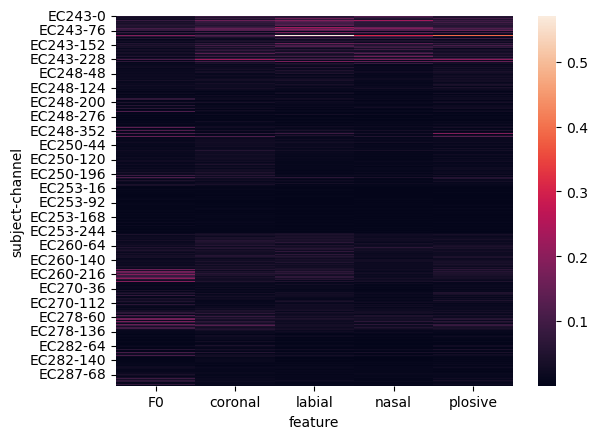

In [18]:
sns.heatmap(timit_coef_results_df_wide)

## Discover Barakeet tuning

In [19]:
barakeet_contrast_windows = [(0.0, 0.1), (0.1, 0.2), (0.2, 0.3)]
barakeet_contrast_results = []

### Categorical acoustic tuning

In [20]:
for subject, epochs_s in tqdm(epochs.items()):
    for phoneme_pair in tqdm(all_md.phoneme_pair.unique(), leave=False):
        phoneme1, phoneme2 = list(phoneme_pair.upper())
        
        ph1_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and categorical_acoustic_cue == -1"]
        ph2_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and categorical_acoustic_cue == 1"]

        for contrast_start, contrast_end in barakeet_contrast_windows:
            ph1_contrast = ph1_epochs.copy().crop(contrast_start, contrast_end).average()
            ph2_contrast = ph2_epochs.copy().crop(contrast_start, contrast_end).average()
            
            for channel in range(ph1_contrast.data.shape[0]):
                if filter_barakeet_by_eoi and (subject, channel) not in eoi_df.index:
                    continue
                t, p = ttest_ind(ph1_contrast.data[channel, :], ph2_contrast.data[channel, :])

                barakeet_contrast_results.append({
                    "subject": subject,
                    "phoneme_pair": phoneme_pair,
                    "feature": "categorical_acoustic",
                    "contrast_start": contrast_start,
                    "contrast_end": contrast_end,
                    "channel": channel,
                    "t": t,
                    "p": p,
                })

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [21]:
# lexical evidence cue
for subject, epochs_s in tqdm(epochs.items()):
    for phoneme_pair in tqdm(all_md.phoneme_pair.unique(), leave=False):
        phoneme1, phoneme2 = list(phoneme_pair.upper())
        
        ph1_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and lexical_evidence_cue == -1"]
        ph2_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and lexical_evidence_cue == 1"]

        base_time = POD_dict[phoneme_pair]

        for contrast_start, contrast_end in barakeet_contrast_windows:
            contrast_start += base_time
            contrast_end += base_time

            ph1_contrast = ph1_epochs.copy().crop(contrast_start, contrast_end).average()
            ph2_contrast = ph2_epochs.copy().crop(contrast_start, contrast_end).average()
            
            for channel in range(ph1_contrast.data.shape[0]):
                if filter_barakeet_by_eoi and (subject, channel) not in eoi_df.index:
                    continue
                t, p = ttest_ind(ph1_contrast.data[channel, :], ph2_contrast.data[channel, :])

                barakeet_contrast_results.append({
                    "subject": subject,
                    "phoneme_pair": phoneme_pair,
                    "feature": "lexical_evidence",
                    "contrast_start": contrast_start,
                    "contrast_end": contrast_end,
                    "channel": channel,
                    "t": t,
                    "p": p,
                })

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
# mismatch cue
for subject, epochs_s in tqdm(epochs.items()):
    for phoneme_pair in tqdm(all_md.phoneme_pair.unique(), leave=False):
        phoneme1, phoneme2 = list(phoneme_pair.upper())
        
        ph1_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and mismatch_left_right == -1"]
        ph2_epochs = epochs_s[f"phoneme_pair == '{phoneme_pair}' and mismatch_left_right == 1"]

        base_time = POD_dict[phoneme_pair]

        for contrast_start, contrast_end in barakeet_contrast_windows:
            contrast_start += base_time
            contrast_end += base_time

            ph1_contrast = ph1_epochs.copy().crop(contrast_start, contrast_end).average()
            ph2_contrast = ph2_epochs.copy().crop(contrast_start, contrast_end).average()
            
            for channel in range(ph1_contrast.data.shape[0]):
                if filter_barakeet_by_eoi and (subject, channel) not in eoi_df.index:
                    continue
                t, p = ttest_ind(ph1_contrast.data[channel, :], ph2_contrast.data[channel, :])

                barakeet_contrast_results.append({
                    "subject": subject,
                    "phoneme_pair": phoneme_pair,
                    "feature": "mismatch",
                    "contrast_start": contrast_start,
                    "contrast_end": contrast_end,
                    "channel": channel,
                    "t": t,
                    "p": p,
                })

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

### Merge

In [23]:
barakeet_contrast_results_df = pd.DataFrame(barakeet_contrast_results)
barakeet_contrast_results_df["sign"] = np.sign(barakeet_contrast_results_df.t)
barakeet_contrast_results_df["preference"] = np.where(barakeet_contrast_results_df.sign == 1, barakeet_contrast_results_df.phoneme_pair.str[0], barakeet_contrast_results_df.phoneme_pair.str[1])
barakeet_contrast_results_df

,subject,phoneme_pair,feature,contrast_start,contrast_end,channel,t,p,sign,preference
0,EC279,bm,categorical_acoustic,0.00,0.10,6,0.083168,0.934545,1.0,b
1,EC279,bm,categorical_acoustic,0.00,0.10,7,0.555645,0.584616,1.0,b
2,EC279,bm,categorical_acoustic,0.00,0.10,22,0.151906,0.880783,1.0,b
3,EC279,bm,categorical_acoustic,0.00,0.10,164,-2.819111,0.010599,-1.0,m
4,EC279,bm,categorical_acoustic,0.10,0.20,6,6.925603,0.000001,1.0,b
...,...,...,...,...,...,...,...,...,...,...
2182,EC250,pb,mismatch,0.31,0.41,215,1.393417,0.178787,1.0,p
2183,EC250,pb,mismatch,0.31,0.41,216,-3.778147,0.001181,-1.0,b
2184,EC250,pb,mismatch,0.41,0.51,202,0.913401,0.371912,1.0,p
2185,EC250,pb,mismatch,0.41,0.51,215,6.861277,0.000001,1.0,p


In [70]:
# Exclude phoneme pair contrasts at a site+feature which are have significant but inconsistent results over time
barakeet_consistent = barakeet_contrast_results_df.query("p < @pval_threshold") \
    .groupby(["subject", "channel", "phoneme_pair", "feature"]).preference.nunique() == 1
barakeet_consistent.value_counts()

preference
True     499
False    103
Name: count, dtype: int64

In [77]:
barakeet_contrast_results_df = \
    pd.merge(barakeet_consistent[barakeet_consistent].rename("__"),
             barakeet_contrast_results_df,
             how="left",
             left_index=True,
             right_on=["subject", "channel", "phoneme_pair", "feature"]).drop(columns=["__"])

In [78]:
barakeet_contrast_results_df.sort_values("p").groupby(["subject", "channel", "feature"]).first().query("p < @pval_threshold")

phoneme_pair  contrast_start  \
subject channel feature                                             
EC243   87      categorical_acoustic           dn            0.20   
                lexical_evidence               bm            0.28   
                mismatch                       bm            0.48   
        90      categorical_acoustic           dn            0.20   
                lexical_evidence               bm            0.38   
...                                           ...             ...   
EC287   56      lexical_evidence               pb            0.31   
                mismatch                       bm            0.48   
        121     categorical_acoustic           bm            0.20   
                lexical_evidence               bm            0.48   
                mismatch                       pb            0.21   

                                      contrast_end          t             p  \
subject channel feature                                                       
EC243   87      categorical_acoustic          0.30   9.521109  7.173894e-09   
                lexical_evidence              0.38   6.537402  2.267496e-06   
                mismatch                      0.58   5.690269  1.437671e-05   
        90      categorical_acoustic          0.30  -7.716461  2.026309e-07   
                lexical_evidence              0.48  10.792979  8.638065e-10   
...                                            ...        ...           ...   
EC287   56      lexical_evidence              0.41  -9.749346  4.839956e-09   
                mismatch                      0.58  11.400437  3.344608e-10   
        121     categorical_acoustic          0.30   9.626819  5.973935e-09   
                lexical_evidence              0.58  10.141944  2.494855e-09   
                mismatch                      0.31   7.907366  1.394803e-07   

                                      sign preference  
subject channel feature                                
EC243   87      categorical_acoustic   1.0          d  
                lexical_evidence       1.0          b  
                mismatch               1.0          b  
        90      categorical_acoustic  -1.0          n  
                lexical_evidence       1.0          b  
...                                    ...        ...  
EC287   56      lexical_evidence      -1.0          b  
                mismatch               1.0          b  
        121     categorical_acoustic   1.0          b  
                lexical_evidence       1.0          b  
                mismatch               1.0          p  

[231 rows x 7 columns]

In [79]:
sig_barakeet_contrasts = barakeet_contrast_results_df.dropna().query("p < @pval_threshold").sort_values("p")
sig_barakeet_contrasts = sig_barakeet_contrasts.drop(columns="sign")
sig_barakeet_contrasts["site"] = sig_barakeet_contrasts.subject.str.cat(sig_barakeet_contrasts.channel.astype(str), sep="_")
sig_barakeet_contrasts

,subject,phoneme_pair,feature,contrast_start,contrast_end,channel,t,p,preference,site
1780,EC253,dn,mismatch,0.395,0.495,37,55.093547,2.553040e-23,d,EC253_37
738,EC279,bm,lexical_evidence,0.480,0.580,7,36.129659,1.086389e-19,b,EC279_7
1056,EC253,dn,lexical_evidence,0.395,0.495,195,32.906118,6.837410e-19,d,EC253_195
1051,EC253,dn,lexical_evidence,0.395,0.495,37,32.663807,7.906226e-19,d,EC253_37
1785,EC253,dn,mismatch,0.395,0.495,195,31.769861,1.363476e-18,d,EC253_195
...,...,...,...,...,...,...,...,...,...,...
1396,EC282,pb,lexical_evidence,0.410,0.510,105,-2.868039,9.507812e-03,b,EC282_105
32,EC279,pb,categorical_acoustic,0.200,0.300,6,-2.867266,9.524182e-03,b,EC279_6
486,EC248,bm,categorical_acoustic,0.100,0.200,366,2.853135,9.828277e-03,b,EC248_366
837,EC260,bm,lexical_evidence,0.280,0.380,76,2.848926,9.920647e-03,b,EC260_76


In [80]:
sig_barakeet_contrasts.groupby(["site"]).apply(lambda xs: xs[["feature", "preference"]].value_counts().idxmax()) \
    .value_counts()

/tmp/ipykernel_2237973/129211784.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sig_barakeet_contrasts.groupby(["site"]).apply(lambda xs: xs[["feature", "preference"]].value_counts().idxmax()) \


(lexical_evidence, b)        26
(categorical_acoustic, b)    21
(mismatch, b)                11
(lexical_evidence, p)         5
(lexical_evidence, d)         4
(mismatch, d)                 4
(mismatch, n)                 2
(categorical_acoustic, m)     2
(lexical_evidence, n)         2
(categorical_acoustic, d)     1
(mismatch, m)                 1
(mismatch, p)                 1
(lexical_evidence, m)         1
Name: count, dtype: int64

## Compare

In [125]:
barakeet_to_merge = barakeet_contrast_results_df.sort_values("p").groupby(["subject", "channel", "phoneme_pair", "feature"]).first()[["t", "p", "preference"]].unstack("feature")
# flatten columns into _ separated names
barakeet_to_merge.columns = ["_".join(col).strip() for col in barakeet_to_merge.columns]
for col in barakeet_to_merge.columns:
    if col.startswith("p_"):
        category = col.replace("p_", "")
        barakeet_to_merge[f"sig_{category}"] = barakeet_to_merge[f"p_{category}"] < pval_threshold

In [82]:
all_contrasts = pd.merge(barakeet_to_merge,
                         contrast_results_df.sort_values("p").groupby(["subject", "channel", "phoneme_pair"]).first()[["t", "p", "preference"]].rename(columns=lambda x: f"{x}_timit"),
                         left_index=True, right_index=True,
                         validate="m:1")
all_contrasts = all_contrasts.reset_index("phoneme_pair")
all_contrasts["site"] = all_contrasts.index.get_level_values("subject").str.cat(all_contrasts.index.get_level_values("channel").astype(str), sep="_")
all_contrasts["sig_timit"] = all_contrasts.p_timit < pval_threshold

In [83]:
# add in EOI information
eoi_df_to_merge = eoi_df.unique_variance.unstack("feature_block").rename(columns=lambda x: f"eoi_uv_{x}").fillna(0)
eoi_df_to_merge.index.names = ["subject", "channel"]
all_contrasts = pd.merge(all_contrasts, eoi_df_to_merge, left_index=True, right_index=True, how="left")

In [84]:
# add in tuning information
all_contrasts = pd.merge(all_contrasts, timit_coef_results_df_wide, on=["subject", "channel"], how="left", validate="m:1")
tuning_margin = 0.02

all_contrasts.loc[(all_contrasts.phoneme_pair == "bm") & (all_contrasts[["labial", "plosive"]].max(1) - all_contrasts.nasal >= tuning_margin), "preference_tuning"] = "b"
all_contrasts.loc[(all_contrasts.phoneme_pair == "bm") & (all_contrasts[["labial", "plosive"]].max(1) - all_contrasts.nasal <= -tuning_margin), "preference_tuning"] = "m"

all_contrasts.loc[(all_contrasts.phoneme_pair == "dn") & (all_contrasts[["coronal", "plosive"]].max(1) - all_contrasts.nasal >= tuning_margin), "preference_tuning"] = "d"
all_contrasts.loc[(all_contrasts.phoneme_pair == "dn") & (all_contrasts[["coronal", "plosive"]].max(1) - all_contrasts.nasal <= -tuning_margin), "preference_tuning"] = "n"

all_contrasts["sig_tuning"] = ~all_contrasts.preference_tuning.isna()

### intra-Barakeet contrasts

In [86]:
all_contrasts[["sig_categorical_acoustic", "sig_lexical_evidence", "sig_mismatch"]].value_counts()

sig_categorical_acoustic  sig_lexical_evidence  sig_mismatch
True                      True                  True            76
False                     True                  True            48
True                      True                  False           31
False                     True                  False           21
True                      False                 True            20
False                     False                 True            14
True                      False                 False           10
Name: count, dtype: int64

### Barakeet tuning vs TIMIT

In [106]:
tuning_comparisons = {}
for tuning_category in ["categorical_acoustic", "lexical_evidence", "mismatch"]:
    print(all_contrasts[["sig_timit", f"sig_{tuning_category}"]].value_counts())
    tuning_comparison = all_contrasts.loc[all_contrasts.sig_timit & all_contrasts[f"sig_{tuning_category}"]].copy()
    tuning_comparison["matched_preference"] = tuning_comparison[f"preference_{tuning_category}"] == tuning_comparison.preference_timit
    tuning_comparisons[tuning_category] = tuning_comparison

sig_timit  sig_categorical_acoustic
False      True                        110
           False                        69
True       True                         27
           False                        14
Name: count, dtype: int64
sig_timit  sig_lexical_evidence
False      True                    146
           False                    33
True       True                     30
           False                    11
Name: count, dtype: int64
sig_timit  sig_mismatch
False      True            125
           False            54
True       True             33
           False             8
Name: count, dtype: int64


In [107]:
tuning_comparisons_df = pd.concat(tuning_comparisons, names=["feature"])

In [108]:
for col in tuning_comparisons_df:
    if "eoi_uv" in col:
        tuning_comparisons_df[f"bool_{col}"] = tuning_comparisons_df[col] > 0

In [109]:
tuning_comparisons_df.groupby("feature").matched_preference.mean()

feature
categorical_acoustic    0.888889
lexical_evidence        0.566667
mismatch                0.303030
Name: matched_preference, dtype: float64

In [111]:
tuning_comparisons_df.groupby(["feature", "bool_eoi_uv_lexical_evidence"]).matched_preference.agg(["count", "mean"])

count      mean
feature              bool_eoi_uv_lexical_evidence                 
categorical_acoustic False                            14  1.000000
                     True                             13  0.769231
lexical_evidence     False                            12  0.666667
                     True                             18  0.500000
mismatch             False                            12  0.166667
                     True                             21  0.380952

In [112]:
tuning_comparisons_df.groupby(["feature", "bool_eoi_uv_mismatch"]).matched_preference.agg(["count", "mean"])

count      mean
feature              bool_eoi_uv_mismatch                 
categorical_acoustic False                    17  0.823529
                     True                     10  1.000000
lexical_evidence     False                    18  0.444444
                     True                     12  0.750000
mismatch             False                    21  0.285714
                     True                     12  0.333333

<Axes: xlabel='bool_eoi_uv_lexical_evidence', ylabel='feature'>

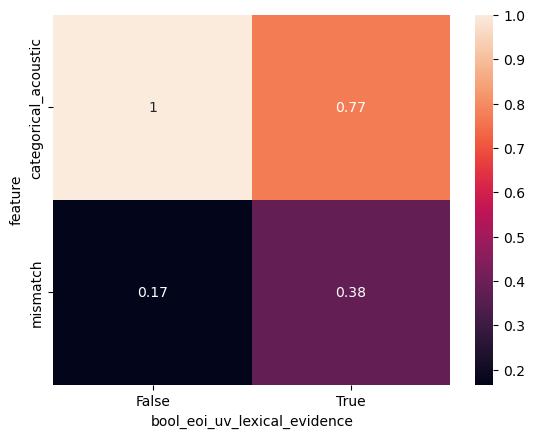

In [136]:
sns.heatmap(tuning_comparisons_df.groupby(["feature", "bool_eoi_uv_lexical_evidence"]).matched_preference.mean().unstack("bool_eoi_uv_lexical_evidence").drop(index=["lexical_evidence"]),
            annot=True)

<Axes: xlabel='bool_eoi_uv_mismatch', ylabel='feature'>

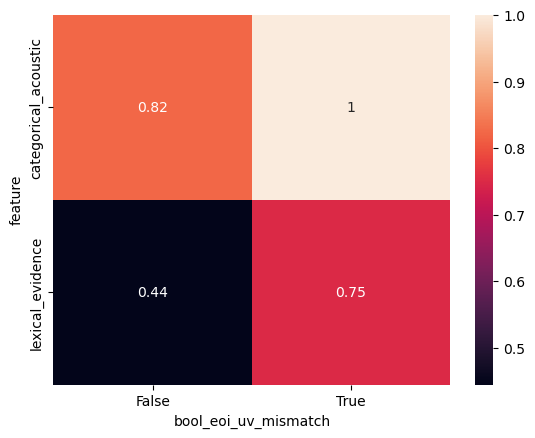

In [134]:
sns.heatmap(tuning_comparisons_df.groupby(["feature", "bool_eoi_uv_mismatch"]).matched_preference.mean().unstack("bool_eoi_uv_mismatch").drop(index=["mismatch"]),
            annot=True)

In [117]:
tuning_comparisons_df.groupby(["feature", "bool_eoi_uv_lexical_evidence", "bool_eoi_uv_mismatch"]).matched_preference.agg(["count", "mean"])

count  \
feature              bool_eoi_uv_lexical_evidence bool_eoi_uv_mismatch          
categorical_acoustic False                        False                     7   
                                                  True                      7   
                     True                         False                    10   
                                                  True                      3   
lexical_evidence     False                        False                     5   
                                                  True                      7   
                     True                         False                    13   
                                                  True                      5   
mismatch             False                        False                     5   
                                                  True                      7   
                     True                         False                    16   
                                                  True                      5   

                                                                            mean  
feature              bool_eoi_uv_lexical_evidence bool_eoi_uv_mismatch            
categorical_acoustic False                        False                 1.000000  
                                                  True                  1.000000  
                     True                         False                 0.700000  
                                                  True                  1.000000  
lexical_evidence     False                        False                 0.800000  
                                                  True                  0.571429  
                     True                         False                 0.307692  
                                                  True                  1.000000  
mismatch             False                        False                 0.200000  
                                                  True                  0.142857  
                     True                         False                 0.312500  
                                                  True                  0.600000

In [129]:
tuning_comparisons_df.loc["categorical_acoustic"] \
    [["phoneme_pair", "bool_eoi_uv_lexical_evidence", "bool_eoi_uv_mismatch", "matched_preference"]] \
    .sort_values(["bool_eoi_uv_lexical_evidence", "bool_eoi_uv_mismatch", "matched_preference"])

phoneme_pair  bool_eoi_uv_lexical_evidence  \
subject channel                                              
EC243   87                bm                         False   
EC253   181               bm                         False   
        181               dn                         False   
        181               pb                         False   
EC260   191               bm                         False   
EC282   84                bm                         False   
        84                dn                         False   
EC243   102               bm                         False   
EC248   381               bm                         False   
        381               dn                         False   
        381               pb                         False   
EC250   215               bm                         False   
        215               dn                         False   
        215               pb                         False   
EC248   382               dn                          True   
EC282   98                pb                          True   
        106               bm                          True   
EC253   21                bm                          True   
        21                pb                          True   
        180               dn                          True   
EC282   101               bm                          True   
        101               dn                          True   
        117               bm                          True   
        117               pb                          True   
EC250   216               bm                          True   
        216               dn                          True   
EC260   206               bm                          True   

                 bool_eoi_uv_mismatch  matched_preference  
subject channel                                            
EC243   87                      False                True  
EC253   181                     False                True  
        181                     False                True  
        181                     False                True  
EC260   191                     False                True  
EC282   84                      False                True  
        84                      False                True  
EC243   102                      True                True  
EC248   381                      True                True  
        381                      True                True  
        381                      True                True  
EC250   215                      True                True  
        215                      True                True  
        215                      True                True  
EC248   382                     False               False  
EC282   98                      False               False  
        106                     False               False  
EC253   21                      False                True  
        21                      False                True  
        180                     False                True  
EC282   101                     False                True  
        101                     False                True  
        117                     False                True  
        117                     False                True  
EC250   216                      True                True  
        216                      True                True  
EC260   206                      True                True

In [118]:
tuning_comparisons_df.to_csv("tuning_comparisons.csv")

## Contrast tables

In [94]:
all_phonemes = sorted(set(itertools.chain.from_iterable(all_contrasts.phoneme_pair.unique())))

In [95]:
all_contrasts[["preference_timit", "preference_categorical_acoustic"]] \
    .value_counts().sort_index().to_frame().pivot_table(index="preference_timit", columns="preference_categorical_acoustic", values="count", fill_value=0).astype(int) \
    .reindex(all_phonemes, axis=0).reindex(all_phonemes, axis=1)

preference_categorical_acoustic,b,d,m,n,p
preference_timit,,,,,
b,38,0,12,0,11
d,0,17,0,6,0
m,13,0,5,0,0
n,0,17,0,9,0
p,6,0,0,0,3


In [96]:
all_contrasts.query("sig_categorical_acoustic and sig_timit")[["preference_timit", "preference_categorical_acoustic"]] \
    .value_counts().sort_index().to_frame().pivot_table(index="preference_timit", columns="preference_categorical_acoustic", values="count", fill_value=0).astype(int) \
    .reindex(all_phonemes, axis=0).reindex(all_phonemes, axis=1).fillna(0).astype(int)

preference_categorical_acoustic,b,d,m,n,p
preference_timit,,,,,
b,16,0,1,0,1
d,0,5,0,0,0
m,0,0,1,0,0
n,0,1,0,2,0
p,0,0,0,0,0


In [97]:
all_contrasts.query("sig_lexical_evidence and sig_timit")[["preference_timit", "preference_lexical_evidence"]] \
    .value_counts().sort_index().to_frame().pivot_table(index="preference_timit", columns="preference_lexical_evidence", values="count", fill_value=0).astype(int) \
    .reindex(all_phonemes, axis=0).reindex(all_phonemes, axis=1).fillna(0).astype(int)

preference_lexical_evidence,b,d,m,n,p
preference_timit,,,,,
b,15,0,0,0,5
d,0,1,0,1,0
m,0,0,0,0,0
n,0,6,0,1,0
p,1,0,0,0,0


In [98]:
all_contrasts.query("sig_mismatch and sig_timit")[["preference_timit", "preference_mismatch"]] \
    .value_counts().sort_index().to_frame().pivot_table(index="preference_timit", columns="preference_mismatch", values="count", fill_value=0).astype(int) \
    .reindex(all_phonemes, axis=0).reindex(all_phonemes, axis=1).fillna(0).astype(int)

preference_mismatch,b,d,m,n,p
preference_timit,,,,,
b,8,0,5,0,6
d,0,0,0,4,0
m,1,0,0,0,0
n,0,6,0,2,0
p,1,0,0,0,0


<Axes: xlabel='None-preference_categorical_acoustic', ylabel='preference_timit'>

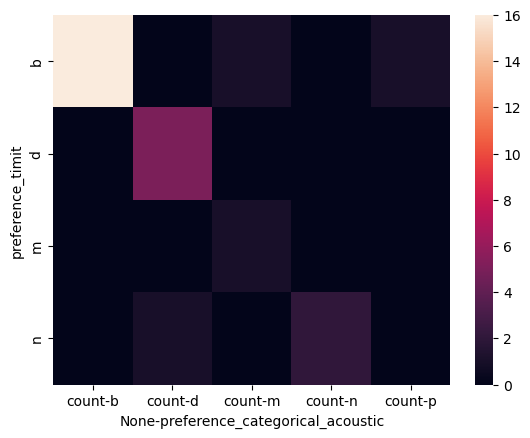

In [99]:
sns.heatmap(all_contrasts.query("sig_categorical_acoustic and sig_timit")[["preference_timit", "preference_categorical_acoustic"]] \
    .value_counts().sort_index().to_frame().pivot_table(index="preference_timit", columns="preference_categorical_acoustic", fill_value=0).astype(int))

In [100]:
all_contrasts.query("sig_tuning and sig_timit and not sig_categorical_acoustic").sort_values("p_categorical_acoustic", ascending=False)

phoneme_pair  t_categorical_acoustic  t_lexical_evidence  \
subject channel                                                            
EC248   235               dn                     NaN            8.709617   
        251               dn                     NaN           27.086528   
EC253   196               dn                     NaN           19.604292   
EC260   206               dn                     NaN           -3.971585   
EC282   116               dn                     NaN                 NaN   
        118               bm                     NaN           12.954792   

                 t_mismatch  p_categorical_acoustic  p_lexical_evidence  \
subject channel                                                           
EC248   235        6.570668                     NaN        3.060438e-08   
        251       16.312808                     NaN        3.088390e-17   
EC253   196       29.007543                     NaN        1.581072e-14   
EC260   206      -11.642081                     NaN        7.518478e-04   
EC282   116        3.980097                     NaN                 NaN   
        118       16.711308                     NaN        3.474165e-11   

                   p_mismatch preference_categorical_acoustic  \
subject channel                                                 
EC248   235      2.112761e-06                             NaN   
        251      5.073019e-13                             NaN   
EC253   196      8.103890e-18                             NaN   
EC260   206      2.317126e-10                             NaN   
EC282   116      7.370355e-04                             NaN   
        118      3.230833e-13                             NaN   

                preference_lexical_evidence preference_mismatch  ...  \
subject channel                                                  ...   
EC248   235                               d                   d  ...   
        251                               d                   d  ...   
EC253   196                               d                   d  ...   
EC260   206                               n                   n  ...   
EC282   116                             NaN                   d  ...   
        118                               b                   b  ...   

                 eoi_uv_behavior  eoi_uv_lexical_evidence  eoi_uv_mismatch  \
subject channel                                                              
EC248   235             0.000000                 0.003112         0.000000   
        251             0.000000                 0.003136         0.000000   
EC253   196             0.000000                 0.000000         0.002091   
EC260   206             0.021535                 0.001077         0.005510   
EC282   116             0.000000                 0.004499         0.000000   
        118             0.000000                 0.005296         0.001479   

                       F0   coronal    labial     nasal   plosive  \
subject channel                                                     
EC248   235      0.146267  0.055139  0.018691  0.028087  0.036393   
        251      0.194556  0.085581  0.043924  0.034105  0.063698   
EC253   196      0.053342  0.040515  0.008436  0.014224  0.018590   
EC260   206      0.169613  0.223005  0.062993  0.131701  0.059526   
EC282   116      0.072564  0.035658  0.014577  0.013443  0.011930   
        118      0.134845  0.074503  0.042154  0.013578  0.076759   

                 preference_tuning  sig_tuning  
subject channel                                 
EC248   235                      d        True  
        251                      d        True  
EC253   196                      d        True  
EC260   206                      d        True  
EC282   116                      d        True  
        118                      b        True  

[6 rows x 29 columns]